# Phase 3d — SpecAugment + Mixup Ablation Study
**Project:** Robust Respiratory Sound Classification under Noise and Domain Shift using Audio Spectrogram Transformers

**Goal this notebook:** isolate the effect of two augmentation techniques -- SpecAugment and Mixup -- independent of the loss-function experiments (CE/Focal/SupCon) run so far. Four configurations, same everything else (data, model, hyperparameters), so any difference in the result is attributable to the augmentation alone:

| Config | SpecAugment | Mixup |
|---|---|---|
| `baseline` | No | No |
| `specaugment` | Yes | No |
| `mixup` | No | Yes |
| `both` | Yes | Yes |

SupCon used SpecAugment *mechanically* -- to generate two different "views" for the contrastive objective, which is required for SupCon to function at all, not optional. Here, SpecAugment is being tested *as an ablation* -- does it help generalization on its own, applied as a single-view training-time augmentation, the way most non-contrastive papers use it. These are two different roles for the same technique, and conflating them would make it unclear which effect produced which result.

**Loss function used throughout:** Focal Loss (the corrected version from `03b`), kept fixed across all four configs. This is a deliberate simplification -- if SupCon (`03c`) turns out to beat Focal Loss on its own, re-run this same ablation with SupCon's combined loss substituted in; the augmentation functions themselves don't change.

**Required inputs for this notebook (Add Input on Kaggle):**
1. `03-ast-finetuning-ce` -- for cached raw waveforms
2. `01-data-preparation` -- for `splits/train.csv`, `val.csv`, `test.csv`

**Compute note:** four full training runs. Each config is independent in the loop below -- comment out any you don't want to run in a given session, rather than assuming all four complete unattended.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt
import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler


from transformers import ASTFeatureExtractor, ASTForAudioClassification, get_linear_schedule_with_warmup

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.dpi"] = 110

## **1. Config**



In [2]:
# =========================
# Reproducibility
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# =========================
# Paths
# =========================
PHASE1_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/01-data-preparation/icbhi_processed"
)
SPLIT_DIR = PHASE1_DIR / "splits"

CE_NOTEBOOK_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/03a-ast-finetuning-ce"
)
WAVEFORM_CACHE_DIR = CE_NOTEBOOK_DIR / "waveform_cache"

CHECKPOINT_DIR = Path("/kaggle/working/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = Path("/kaggle/working/results_phase3d.csv")


# =========================
# Labels
# =========================
LABELS = ["normal", "crackle", "wheeze", "both"]


# =========================
# Audio preprocessing constants 
# =========================
TARGET_SR = 16000
LOWCUT = 50
HIGHCUT = 8000
TARGET_DURATION = 8.0


# =========================
# AST model config
# =========================
AST_CHECKPOINT = "MIT/ast-finetuned-audioset-10-10-0.4593"


# =========================
# Training config 
# =========================
BATCH_SIZE = 8
NUM_WORKERS = 2
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
MAX_EPOCHS = 15
EARLY_STOP_PATIENCE = 4
GRAD_CLIP_NORM = 1.0

FOCAL_GAMMA = 2.0

# SpecAugment
TIME_MASK_PARAM = 100
FREQ_MASK_PARAM = 20
N_TIME_MASKS = 2
N_FREQ_MASKS = 2

# Mixup
MIXUP_ALPHA = 0.4   # standard default (Zhang et al., 2017); higher = more
                

# Which configs to run this session -- comment out any you want to skip
CONFIGS_TO_RUN = ["baseline", "specaugment", "mixup", "both"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
assert DEVICE.type == "cuda" # "Enable the GPU accelerator for this notebook before continuing.

Device: cuda


## **2. Load splits + resolve cached waveforms**

In [3]:
train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df   = pd.read_csv(SPLIT_DIR / "val.csv")
test_df  = pd.read_csv(SPLIT_DIR / "test.csv")

required_cols = {"audio_path", "start", "end", "label"}
missing = required_cols - set(train_df.columns)
assert not missing, f"Missing expected columns: {missing}"

print(train_df.shape, val_df.shape, test_df.shape)


(4580, 14) (1133, 14) (1185, 14)


In [4]:
from pathlib import Path

def resolve_waveform_path(row, cache_dir=WAVEFORM_CACHE_DIR):
    # Recreate the exact filename used during Phase 1
    cycle_id = f"{Path(row['audio_path']).stem}_{float(row['start'])}_{float(row['end'])}"
    
    waveform_path = cache_dir / f"{cycle_id}.npy"

    # look for the existing waveform.
    # do NOT regenerate it.
    if not waveform_path.exists():
        raise FileNotFoundError(
            f"Waveform not found:\n{waveform_path}"
        )

    return str(waveform_path)


# Create waveform_path column for all splits
for name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df)
]:
    df["waveform_path"] = [
        resolve_waveform_path(row)
        for _, row in df.iterrows()
    ]

    print(f"{name}: {len(df)} waveform paths created")

print("\nAll waveform paths resolved successfully.")

train: 4580 waveform paths created
val: 1133 waveform paths created
test: 1185 waveform paths created

All waveform paths resolved successfully.


In [5]:
train_df.head() # check

,cycle_id,patient_id,recording_id,chest_location,acquisition_mode,equipment,audio_path,start,end,crackle,wheeze,label,duration,spectrogram_path,waveform_path
0,101_1b1_Al_sc_Meditron_0,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,0.036,0.579,0,0,normal,0.543,/kaggle/working/icbhi_processed/spectrograms/1...,/kaggle/input/notebooks/praveshsubba/03a-ast-f...
1,101_1b1_Al_sc_Meditron_1,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,0.579,2.450,0,0,normal,1.871,/kaggle/working/icbhi_processed/spectrograms/1...,/kaggle/input/notebooks/praveshsubba/03a-ast-f...
2,101_1b1_Al_sc_Meditron_2,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,2.450,3.893,0,0,normal,1.443,/kaggle/working/icbhi_processed/spectrograms/1...,/kaggle/input/notebooks/praveshsubba/03a-ast-f...
3,101_1b1_Al_sc_Meditron_3,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,3.893,5.793,0,0,normal,1.900,/kaggle/working/icbhi_processed/spectrograms/1...,/kaggle/input/notebooks/praveshsubba/03a-ast-f...
4,101_1b1_Al_sc_Meditron_4,101,1b1,Al,sc,Meditron,/kaggle/input/datasets/husninm/icbhi-2017-chal...,5.793,7.521,0,0,normal,1.728,/kaggle/working/icbhi_processed/spectrograms/1...,/kaggle/input/notebooks/praveshsubba/03a-ast-f...


## **3. Augmentation functions**

**SpecAugment:** same time/frequency masking as `03c`, applied once per sample here (single view -- this notebook doesn't need contrastive pairs).

**Mixup:** blends two randomly-paired spectrograms and their labels using a weight `lam` drawn from a Beta distribution. Unlike SpecAugment (which distorts one example), Mixup creates an entirely new, synthetic training example that's a linear interpolation between two real ones -- the model is trained to predict the corresponding interpolated label distribution, not a single class. This works at the *batch* level (needs pairs), so it's implemented inside the training step rather than the `Dataset`.

In [6]:
def spec_augment(x, time_mask_param=TIME_MASK_PARAM, freq_mask_param=FREQ_MASK_PARAM,n_time_masks=N_TIME_MASKS, n_freq_masks=N_FREQ_MASKS):
    x = x.clone()
    T, M = x.shape
    fill_value = x.mean()
    for _ in range(n_time_masks):
        t = np.random.randint(0, time_mask_param)
        t0 = np.random.randint(0, max(T - t, 1))
        x[t0:t0 + t, :] = fill_value
    for _ in range(n_freq_masks):
        f = np.random.randint(0, freq_mask_param)
        f0 = np.random.randint(0, max(M - f, 1))
        x[:, f0:f0 + f] = fill_value
    return x


def mixup_batch(x, y, alpha=MIXUP_ALPHA):
    """x: (B, 1024, 128), y: (B,) integer labels.
    Returns mixed x, and (y_a, y_b, lam) so the loss can be computed as
    lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b).
    """
    batch_size = x.size(0)
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    perm = torch.randperm(batch_size, device=x.device)

    x_mixed = lam * x + (1 - lam) * x[perm]
    y_a, y_b = y, y[perm]
    return x_mixed, y_a, y_b, lam

## **4. Dataset -- augmentation is applied per-config at training time**

One dataset class handles both SpecAugment-on/off; Mixup is applied later at the batch level inside the training loop, since it needs a paired second example from the same batch.

In [7]:
feature_extractor = ASTFeatureExtractor.from_pretrained(AST_CHECKPOINT)

class ASTLungSoundDataset(Dataset):
    def __init__(self, df, feature_extractor, label_list=LABELS, use_specaugment=False):
        self.df = df.reset_index(drop=True)
        self.fe = feature_extractor
        self.label2idx = {l: i for i, l in enumerate(label_list)}
        self.use_specaugment = use_specaugment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform = np.load(row["waveform_path"])
        features = self.fe(waveform, sampling_rate=TARGET_SR, return_tensors="pt")
        x = features["input_values"].squeeze(0)

        if self.use_specaugment:
            x = spec_augment(x)

        y = torch.tensor(self.label2idx[row["label"]], dtype=torch.long)
        return x, y


def make_loaders(use_specaugment):
    train_ds = ASTLungSoundDataset(train_df, feature_extractor, use_specaugment=use_specaugment)
    val_ds   = ASTLungSoundDataset(val_df,   feature_extractor, use_specaugment=False)
    test_ds  = ASTLungSoundDataset(test_df,  feature_extractor, use_specaugment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    return train_loader, val_loader, test_loader

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

## **5. Focal Loss (reused, unchanged) + shared ICBHI Score**

In [8]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        p_t = torch.exp(-ce_loss)
        focal_term = (1 - p_t) ** self.gamma
        loss = focal_term * ce_loss
        if self.alpha is not None:
            loss = self.alpha[targets] * loss
        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


def icbhi_score(y_true_labels, y_pred_labels):
    y_true_abn = np.array([l != "normal" for l in y_true_labels])
    y_pred_abn = np.array([l != "normal" for l in y_pred_labels])
    normal_mask = ~y_true_abn
    specificity = (~y_pred_abn[normal_mask]).sum() / normal_mask.sum()
    abnormal_mask = y_true_abn
    sensitivity = y_pred_abn[abnormal_mask].sum() / abnormal_mask.sum()
    score = (sensitivity + specificity) / 2
    return {"sensitivity": sensitivity, "specificity": specificity, "icbhi_score": score}


idx2label = {i: l for i, l in enumerate(LABELS)}

def evaluate_and_report(y_true, y_pred, model_name):
    scores = icbhi_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"Sensitivity: {scores['sensitivity']*100:.2f}%")
    print(f"Specificity: {scores['specificity']*100:.2f}%")
    print(f"ICBHI Score:  {scores['icbhi_score']*100:.2f}%\n")
    print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{model_name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return scores


results_log = []

def log_result(model_name, split, scores, notes=""):
    results_log.append({
        "model": model_name, "split": split,
        "sensitivity": scores["sensitivity"], "specificity": scores["specificity"],
        "icbhi_score": scores["icbhi_score"], "notes": notes,
    })
    pd.DataFrame(results_log).to_csv(RESULTS_CSV, index=False)


class_counts = train_df["label"].value_counts().reindex(LABELS).fillna(0)
class_weights = (1.0 / class_counts).values
class_weights = class_weights / class_weights.sum() * len(LABELS)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

## **6. Training loop -- parameterized by config**

One function handles all four configs; `use_mixup` controls whether `mixup_batch` is applied inside the loop. When Mixup is on, the loss is computed as a weighted blend against both of Mixup's synthetic labels (`y_a`, `y_b`) rather than a single target -- this is why `FocalLoss` needing a `reduction="none"` option (already built in) matters here.

In [9]:
def train_epoch(model, loader, criterion, optimizer, scheduler, scaler, use_mixup):
    model.train()
    total_loss = 0.0
    n_samples = 0

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()

        with autocast("cuda"):
            if use_mixup:
                x_mixed, y_a, y_b, lam = mixup_batch(xb, yb)
                logits = model(input_values=x_mixed).logits
                loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)
            else:
                logits = model(input_values=xb).logits
                loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scale_before = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        if scaler.get_scale() >= scale_before:
            scheduler.step()

        total_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)

    return total_loss / n_samples


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    n_samples = 0
    all_true, all_pred = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            with autocast("cuda"):
                logits = model(input_values=xb).logits
                loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            n_samples += xb.size(0)
            preds = logits.argmax(dim=1)
            all_true.extend(idx2label[i] for i in yb.cpu().numpy())
            all_pred.extend(idx2label[i] for i in preds.cpu().numpy())

    return total_loss / n_samples, icbhi_score(all_true, all_pred), all_true, all_pred


def run_config(config_name, use_specaugment, use_mixup):
    print(f"\n{'='*60}\nRunning config: {config_name}\n{'='*60}")

    model = ASTForAudioClassification.from_pretrained(
        AST_CHECKPOINT, num_labels=len(LABELS),
        id2label={i: l for i, l in enumerate(LABELS)}, label2id={l: i for i, l in enumerate(LABELS)},
        ignore_mismatched_sizes=True,
    ).to(DEVICE)

    criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    train_loader, val_loader, test_loader = make_loaders(use_specaugment=use_specaugment)
    total_steps = len(train_loader) * MAX_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    scaler = torch.amp.GradScaler("cuda")

    best_val_score = -1
    epochs_without_improvement = 0
    checkpoint_path = CHECKPOINT_DIR / f"ast_{config_name}_best.pt"

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, scheduler, scaler, use_mixup)
        val_loss, val_scores, _, _ = eval_epoch(model, val_loader, criterion)

        print(f"[{config_name}] Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | val_ICBHI_score={val_scores['icbhi_score']*100:.2f}%")

        if val_scores["icbhi_score"] > best_val_score:
            best_val_score = val_scores["icbhi_score"]
            epochs_without_improvement = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(torch.load(checkpoint_path))
    _, val_scores, val_true, val_pred = eval_epoch(model, val_loader, criterion)
    evaluate_and_report(val_true, val_pred, f"{config_name} (val)")
    log_result(f"AST + Focal + {config_name}", "val", val_scores)

    _, test_scores, test_true, test_pred = eval_epoch(model, test_loader, criterion)
    evaluate_and_report(test_true, test_pred, f"{config_name} (TEST)")
    log_result(f"AST + Focal + {config_name}", "test", test_scores)

    return test_scores

## **7. Run the selected configs**

Each entry: `(config_name, use_specaugment, use_mixup)`. Filtered by `CONFIGS_TO_RUN` from the config cell -- comment configs out there, not here, so the mapping stays in one place.


Running config: baseline


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


[baseline] Epoch 01 | train_loss=0.3907 | val_loss=0.2635 | val_ICBHI_score=70.33%
[baseline] Epoch 02 | train_loss=0.2505 | val_loss=0.2947 | val_ICBHI_score=57.61%
[baseline] Epoch 03 | train_loss=0.1509 | val_loss=0.4064 | val_ICBHI_score=63.27%
[baseline] Epoch 04 | train_loss=0.0730 | val_loss=0.4304 | val_ICBHI_score=66.63%
[baseline] Epoch 05 | train_loss=0.0291 | val_loss=0.7429 | val_ICBHI_score=68.75%
Early stopping at epoch 5
--- baseline (val) ---
Sensitivity: 54.68%
Specificity: 85.97%
ICBHI Score:  70.33%

              precision    recall  f1-score   support

      normal       0.73      0.86      0.79       663
     crackle       0.65      0.37      0.47       347
      wheeze       0.47      0.76      0.58        66
        both       0.38      0.32      0.35        57

    accuracy                           0.68      1133
   macro avg       0.56      0.58      0.55      1133
weighted avg       0.67      0.68      0.66      1133



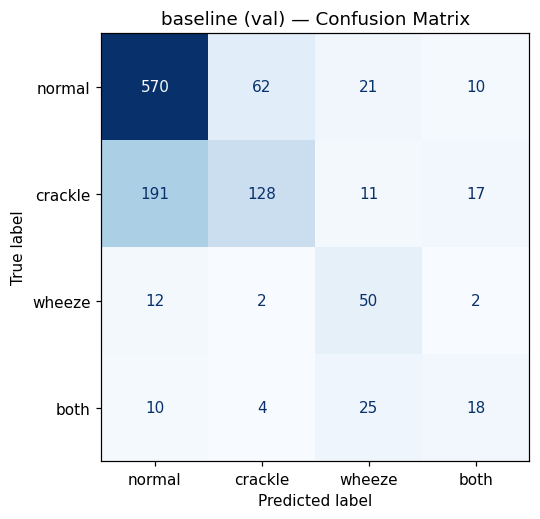

--- baseline (TEST) ---
Sensitivity: 48.53%
Specificity: 79.69%
ICBHI Score:  64.11%

              precision    recall  f1-score   support

      normal       0.70      0.80      0.74       709
     crackle       0.62      0.13      0.22       298
      wheeze       0.28      0.55      0.37       104
        both       0.29      0.42      0.34        74

    accuracy                           0.58      1185
   macro avg       0.47      0.47      0.42      1185
weighted avg       0.62      0.58      0.55      1185



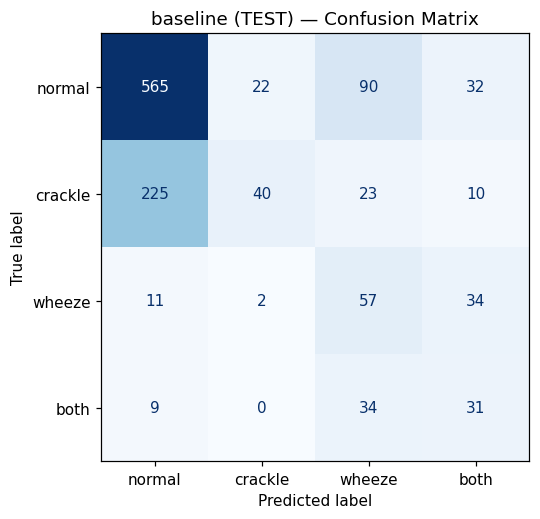


Running config: specaugment


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


[specaugment] Epoch 01 | train_loss=0.4359 | val_loss=0.2694 | val_ICBHI_score=69.53%
[specaugment] Epoch 02 | train_loss=0.3098 | val_loss=0.2561 | val_ICBHI_score=71.25%
[specaugment] Epoch 03 | train_loss=0.2345 | val_loss=0.3586 | val_ICBHI_score=63.75%
[specaugment] Epoch 04 | train_loss=0.1621 | val_loss=0.4812 | val_ICBHI_score=68.35%
[specaugment] Epoch 05 | train_loss=0.1394 | val_loss=0.3783 | val_ICBHI_score=66.00%
[specaugment] Epoch 06 | train_loss=0.0978 | val_loss=0.5414 | val_ICBHI_score=66.87%
Early stopping at epoch 6
--- specaugment (val) ---
Sensitivity: 80.21%
Specificity: 62.29%
ICBHI Score:  71.25%

              precision    recall  f1-score   support

      normal       0.82      0.62      0.71       663
     crackle       0.51      0.72      0.59       347
      wheeze       0.55      0.62      0.59        66
        both       0.32      0.35      0.34        57

    accuracy                           0.64      1133
   macro avg       0.55      0.58      0.56 

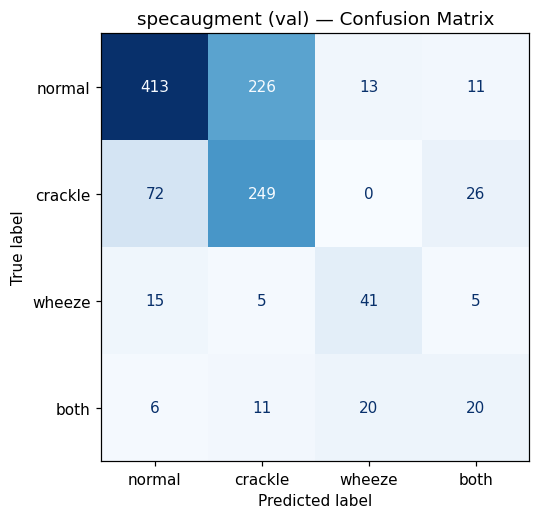

--- specaugment (TEST) ---
Sensitivity: 61.55%
Specificity: 66.71%
ICBHI Score:  64.13%

              precision    recall  f1-score   support

      normal       0.72      0.67      0.69       709
     crackle       0.51      0.37      0.43       298
      wheeze       0.21      0.40      0.28       104
        both       0.27      0.42      0.33        74

    accuracy                           0.55      1185
   macro avg       0.43      0.47      0.43      1185
weighted avg       0.60      0.55      0.57      1185



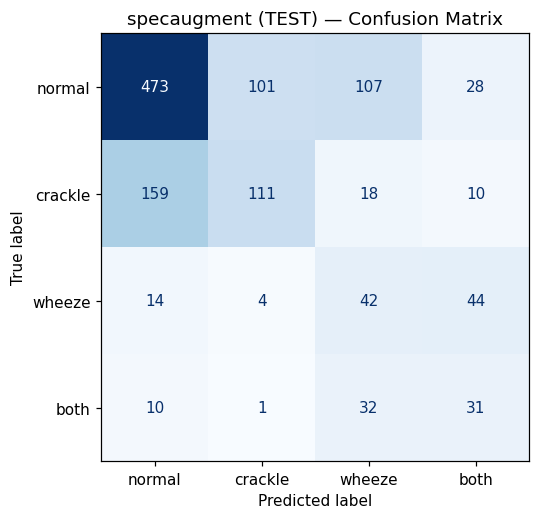


Running config: mixup


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


[mixup] Epoch 01 | train_loss=0.4456 | val_loss=0.2840 | val_ICBHI_score=58.84%
[mixup] Epoch 02 | train_loss=0.3416 | val_loss=0.3073 | val_ICBHI_score=67.37%
[mixup] Epoch 03 | train_loss=0.2787 | val_loss=0.3974 | val_ICBHI_score=70.75%
[mixup] Epoch 04 | train_loss=0.2401 | val_loss=0.3283 | val_ICBHI_score=68.11%
[mixup] Epoch 05 | train_loss=0.1963 | val_loss=0.3170 | val_ICBHI_score=67.10%
[mixup] Epoch 06 | train_loss=0.1791 | val_loss=0.4149 | val_ICBHI_score=64.92%
[mixup] Epoch 07 | train_loss=0.1674 | val_loss=0.4158 | val_ICBHI_score=68.28%
Early stopping at epoch 7
--- mixup (val) ---
Sensitivity: 66.38%
Specificity: 75.11%
ICBHI Score:  70.75%

              precision    recall  f1-score   support

      normal       0.76      0.75      0.76       663
     crackle       0.55      0.58      0.56       347
      wheeze       0.39      0.67      0.49        66
        both       1.00      0.02      0.03        57

    accuracy                           0.66      1133
   mac

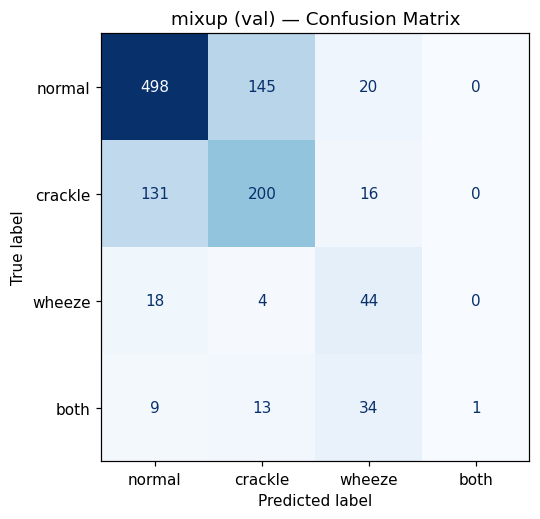

--- mixup (TEST) ---
Sensitivity: 50.42%
Specificity: 81.66%
ICBHI Score:  66.04%

              precision    recall  f1-score   support

      normal       0.71      0.82      0.76       709
     crackle       0.50      0.26      0.34       298
      wheeze       0.37      0.71      0.49       104
        both       0.56      0.12      0.20        74

    accuracy                           0.62      1185
   macro avg       0.54      0.48      0.45      1185
weighted avg       0.62      0.62      0.60      1185



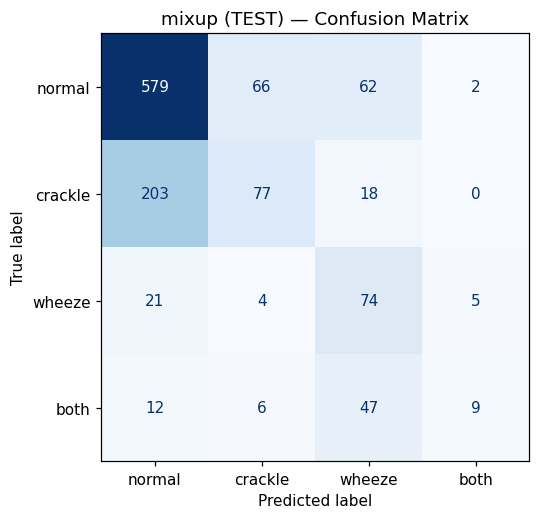


Running config: both


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


[both] Epoch 01 | train_loss=0.4767 | val_loss=0.2665 | val_ICBHI_score=69.16%
[both] Epoch 02 | train_loss=0.3794 | val_loss=0.3012 | val_ICBHI_score=69.21%
[both] Epoch 03 | train_loss=0.3320 | val_loss=0.2795 | val_ICBHI_score=61.23%
[both] Epoch 04 | train_loss=0.3036 | val_loss=0.3059 | val_ICBHI_score=66.94%
[both] Epoch 05 | train_loss=0.2559 | val_loss=0.3146 | val_ICBHI_score=67.31%
[both] Epoch 06 | train_loss=0.2512 | val_loss=0.3381 | val_ICBHI_score=67.96%
Early stopping at epoch 6
--- both (val) ---
Sensitivity: 74.47%
Specificity: 63.95%
ICBHI Score:  69.21%

              precision    recall  f1-score   support

      normal       0.78      0.64      0.70       663
     crackle       0.48      0.46      0.47       347
      wheeze       0.38      0.73      0.50        66
        both       0.10      0.23      0.14        57

    accuracy                           0.57      1133
   macro avg       0.43      0.51      0.45      1133
weighted avg       0.63      0.57      

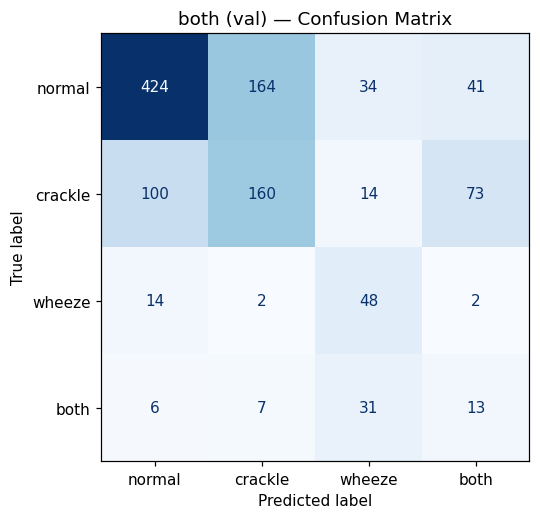

--- both (TEST) ---
Sensitivity: 66.60%
Specificity: 67.84%
ICBHI Score:  67.22%

              precision    recall  f1-score   support

      normal       0.75      0.68      0.71       709
     crackle       0.59      0.29      0.38       298
      wheeze       0.26      0.77      0.39       104
        both       0.23      0.28      0.26        74

    accuracy                           0.56      1185
   macro avg       0.46      0.50      0.43      1185
weighted avg       0.63      0.56      0.57      1185



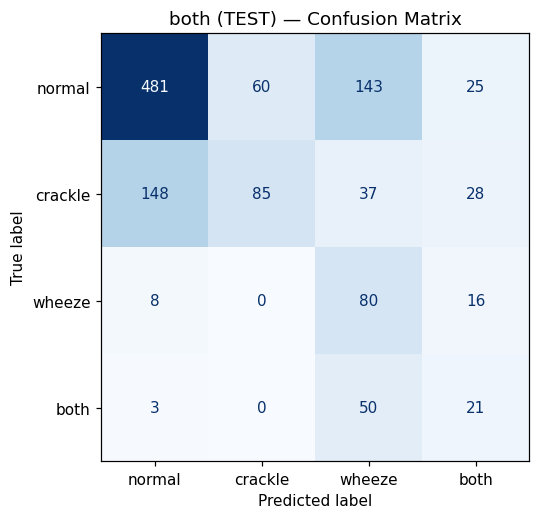

In [10]:
ALL_CONFIGS = {
    "baseline":     (False, False),
    "specaugment":  (True,  False),
    "mixup":        (False, True),
    "both":         (True,  True),
}

config_results = {}
for name in CONFIGS_TO_RUN:
    use_sa, use_mu = ALL_CONFIGS[name]
    config_results[name] = run_config(name, use_specaugment=use_sa, use_mixup=use_mu)

## **8. Comparison table + chart**

                       model split  sensitivity  specificity  icbhi_score  \
7         AST + Focal + both  test        66.60        67.84        67.22   
5        AST + Focal + mixup  test        50.42        81.66        66.04   
3  AST + Focal + specaugment  test        61.55        66.71        64.13   
1     AST + Focal + baseline  test        48.53        79.69        64.11   

  notes  
7        
5        
3        
1        


/tmp/ipykernel_22/2569213939.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(test_only["model"], rotation=20, ha="right")


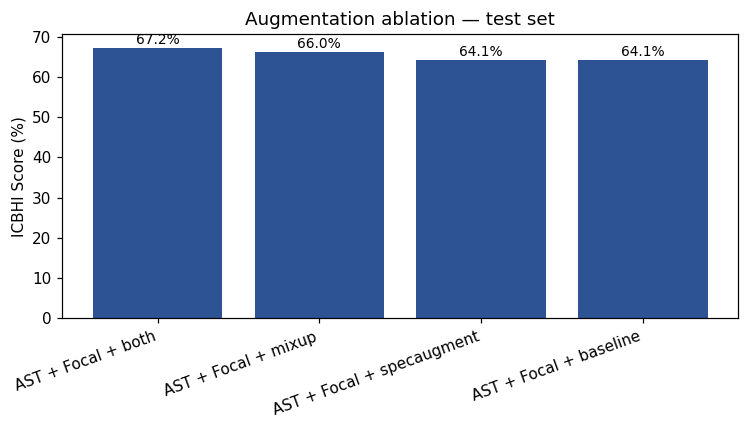

In [11]:
results_df = pd.DataFrame(results_log)
results_df["sensitivity"] = (results_df["sensitivity"] * 100).round(2)
results_df["specificity"] = (results_df["specificity"] * 100).round(2)
results_df["icbhi_score"] = (results_df["icbhi_score"] * 100).round(2)

display_cols = ["model", "split", "sensitivity", "specificity", "icbhi_score", "notes"]
results_df[display_cols].to_csv(RESULTS_CSV, index=False)

test_only = results_df[results_df["split"] == "test"].sort_values("icbhi_score", ascending=False)
print(test_only[display_cols])

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(test_only["model"], test_only["icbhi_score"], color="#2E5395")
ax.set_xticklabels(test_only["model"], rotation=20, ha="right")
ax.set_ylabel("ICBHI Score (%)")
ax.set_title("Augmentation ablation — test set")
for i, v in enumerate(test_only["icbhi_score"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## **9. Phase 3D Summary — Augmentation Ablation**

This experiment evaluates four AST training configurations using focal loss: a baseline without augmentation, SpecAugment alone, Mixup alone, and both augmentations together.

### Method

* Reused existing waveform caches and the project's patient-level 70/15/15 split.
* Applied SpecAugment as a single-view training-time augmentation.
* Applied Mixup at the batch level with interpolated labels.
* Kept the configured model, loss and training settings consistent across configurations.
* Evaluated the completed configurations and exported their metrics to `results_phase3d.csv`.

### Interpretation

The recorded results show how these augmentation configurations performed under this experiment's setup. The combined configuration should not be assumed to outperform the individual techniques; conclusions must follow the measured results.

### Limitations

The results use the internal patient-level split and do not directly establish performance under the official ICBHI evaluation protocol. Test results are evaluation measurements, not a tuning target.
